# Data Analysis and Preprocessing

In [ ]:
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
import pandas as pd
import numpy as np
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

First, we load our data:

In [ ]:
def load_housing_data():
  tarball_path = Path("housing.tgz")
  if not tarball_path.is_file():
    Path("datasets").mkdir(parents=True, exist_ok=True)
    url = "https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
      housing_tarball.extractall(path="datasets")
  return pd.read_csv("datasets/housing/housing.csv")

housing = load_housing_data()

/tmp/ipykernel_866/1928401952.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [ ]:
housing.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Careful: total_bedrooms we have 20433 Non-null instances, while there are 20640 rows. This means we will have to handle these null values.

In [ ]:
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


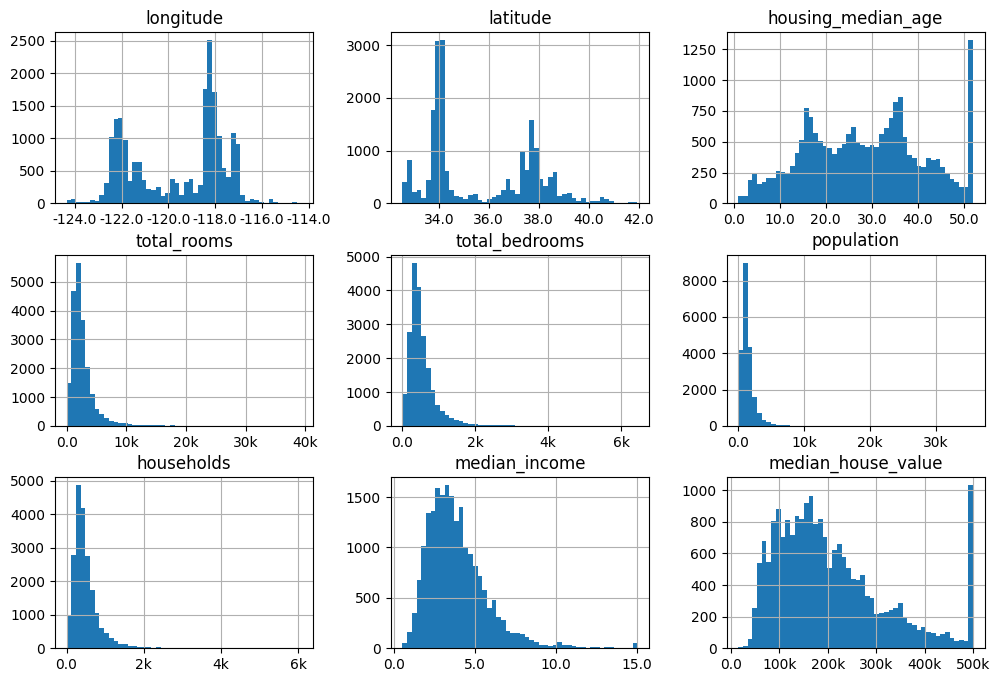

In [ ]:
def format_func(value, tick_number):
    return f'{int(value / 1000)}k' if value >= 1000 else value

axes = housing.hist(bins=50, figsize=(12, 8))
for axis in axes.flat:
  axis.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
plt.show()

Careful: many of the charts are **skewed right**: this might cause some problems in finding patterns. Moreover, some data is stored in a different scale and caps, for example median_income, meaning that you probably have to readapt it.

Now, let's **create a test set.** We just take a random 20% of the dataset

In [ ]:
def shuffle_and_split(data, test_ratio):
  np.random.seed(42)
  shuffled_indices = np.random.permutation(len(data)) # randomly take the indices
  test_set_size = int(len(data) * test_ratio) # get the amount of rows you want
  test_indices = shuffled_indices[:test_set_size] # get the amount of indices you want from the set
  train_indices = shuffled_indices[test_set_size:]
  return data.iloc[train_indices], data.iloc[test_indices]

train_set, test_set = shuffle_and_split(housing, 0.2)
print(f"Train rows count: {len(train_set)}")
print(f"Test rows count: {len(test_set)}")

# You already have this function in sklearn:
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
print(f"Train rows count: {len(train_set)}")
print(f"Test rows count: {len(test_set)}")

Train rows count: 16512
Test rows count: 4128
Train rows count: 16512
Test rows count: 4128


Everytime you sample the dataset you have to ask yourself: *can i randomly sample this?* since you want that the data you sampled is representative of the actual dataset. This is called **stratified sampling**. Suppose you somehow know that median income is a very important attribute to predict house prices. You then want the data sampled to be EXTREMELY representative. Since more median income prices are from 2 to 5 you must get each of them precisely, maybe getting some categories out of that feature.

scikit learn already has a method do stratify, in sklearn.model_selection


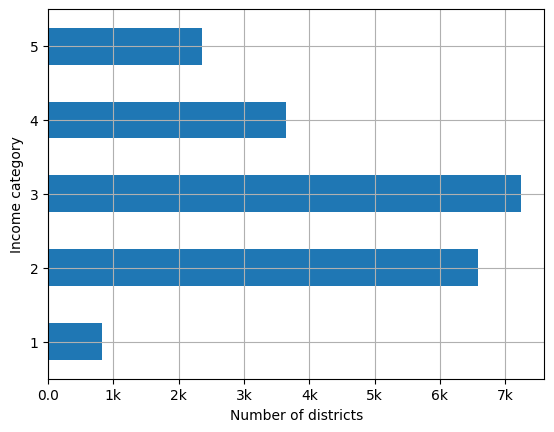

In [ ]:
housing['income_category'] = pd.cut(housing['median_income'],
                                    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
                                    labels=[1, 2, 3, 4, 5])
housing["income_category"].value_counts().sort_index().plot.barh(grid=True)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
plt.xlabel("Number of districts")
plt.ylabel("Income category")
plt.show()

In [ ]:
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []

for train_index, test_index in splitter.split(housing, housing['income_category']):
  strat_train = housing.iloc[train_index] # take the train strata
  strat_test = housing.iloc[test_index] # take the test strata
  strat_splits.append([strat_train, strat_test])

# you can just take the first split
strat_train_set, strat_test_set = strat_splits[0]

# you can do the same in one line
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, random_state=42, stratify=housing['income_category'])

# check if proportions are respected
proportions = strat_test_set['income_category'].value_counts() / len(strat_test_set)
print(f"Proportions: {proportions}")

# This last line is just because you will not actually need this category in the end, drop it
for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_category", axis=1, inplace=True)

Proportions: income_category
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64


So we got a way to make the sample representative. We can now try to see if there are strong correlations in the data, either statistically or by plotting it.

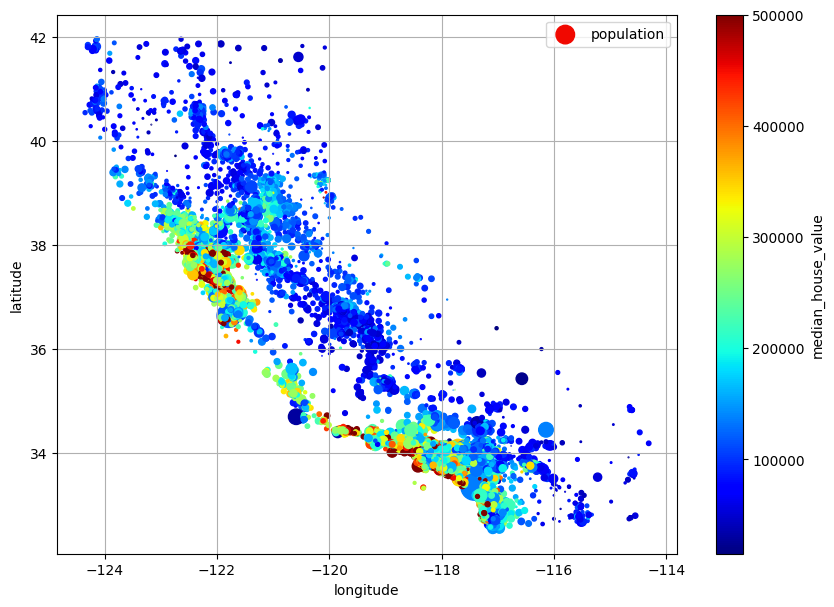

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing['population'] / 100, label="population", c="median_house_value",
             cmap="jet", colorbar=True, legend=True, sharex=False, figsize=(10, 7))
plt.show()

So the geographical location is important. Also:

In [ ]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


Now, before going in the actual machine learning, we can try to combine some attributes to find some new features that might correlate really well to to our target variable.

In [ ]:
housing["rooms_per_house"] = housing['total_rooms'] / housing['households']
housing["bedroom_ratio"] = housing['total_bedrooms'] / housing['total_rooms']
housing["people_per_house"] = housing['population'] / housing['households']

corr_matrix = housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
rooms_per_house,0.151948
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
people_per_house,-0.023737
population,-0.024650
longitude,-0.045967


Apparently houses with a lower bedroom ratio seem to cost less!

Let's now prepare data for the algorithm:

In [ ]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

# Clean the data

# housing.dropna(subset=["total_bedrooms"], inplace=True) # getting rid of only Na
# housing.drop("total_bedrooms", axis=1) # get rid of whole attribute
# housing["total_bedrooms"].fillna(median, inplace=True) # sub with median

Instead of going with 3 which is the least desruptive, you go with a handy scikit learn class, **SimpleImputer**


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing.select_dtypes(include=[np.number]) #get num values
imputer.fit(housing_num)

SimpleImputer(strategy='median')

The imputer calculated the median of each attribute, so now we can access it. We can apply it to each feature but we don't know if we have any missing data, so we apply it to every feature

In [ ]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

We also need to handle categorical and string values. We need to encode it.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

ordinal_encoder, cat_encoder = OrdinalEncoder(), OneHotEncoder()
housing_cat = housing[['ocean_proximity']]

housing_cat.head()

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN


In [ ]:
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [ ]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

The problem with this type of encoding is that there is distance between categories that is uneven. Therefore we use one hot encoding, which represents the categories as a sparse matrix, convertible to dense array using the `toarray()` method in numpy, or using the `sparse_output=False` flag in the `OneHotEncoder`, or last, by using the Pandas function:

In [ ]:
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
# or
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


# Feature scaling and transformation

If the features have very different scales, the algorithms don't perform well. So we need to scale it, using:
- min-max scaling
- standardization

## Min-max scaling

this is basically *normalization*. Shift and rescale so that all values are between min and max.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1)) # this range is a hyperparameter
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

## Standardization

Subtract by mean, divide by stdev. It is much less affected by outliers.

In [ ]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

Both suffer from a heavy tail (values far from mean are not exponentially rare). ML models don't like this. So before scaling,  you must transform it, making the distribution almost symmetrical (taking for example the square root or logarithm) or bucketizing the distribtion (useful with double peaks)

# Model
Now we make experiments with models:

In [ ]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

print(predictions)

[[131997.15275877]
 [299359.35844434]
 [146023.37185694]
 [138840.33653057]
 [192016.61557639]]


In [ ]:
# More compact
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

print(predictions)

[131997.15275877 299359.35844434 146023.37185694 138840.33653057
 192016.61557639]


# Custom Transformer

You can also create your own logic for the transformer, or use a numpy function. In this example we see the log transformer.

In [ ]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp) # inverse_func is optional: if you have it you get basically a TransformedTargetRegressor
log_pop = log_transformer.transform(housing['population'])

Bu what if you wanted to fit to learn some parameters? You need to create your own class

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
  def __init__(self, with_mean=True):
    self.with_mean = with_mean

  def fit(self, X, y=None):
    X = check_array(X)
    self.mean = X.mean(axis=0)
    self.std = X.std(axis=0)
    self.n_features = X.shape[1]
    return self

  def transform(self, X):
    check_is_fitted(self)
    X = check_array(X)
    assert self.n_features == X.shape[1]
    if self.with_mean:
      X = X - self.mean
    return X / self.std

You can check whether your custom estimator respects Scikit-
Learn’s API by passing an instance to `check_estimator()` from
the `sklearn.utils.estimator_checks` package.

# Transformation pipeline

To do many operations in sequence, sklearn offers a package to do them in a pipeline. Here an example to pipeline imputation with median and scaling.

In [ ]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")), # estimators must be transformers (must have a fit_transform method)
    ("scale", StandardScaler())
])

In [ ]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

We can also handle categorical and numerical attributes using the same object. We can use `ColumnTransformer`.

In [ ]:
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
  ("num", num_pipeline, num_attribs),
  ("cat", cat_pipeline, cat_attribs)
])

housing_prepared = preprocessing.fit_transform(housing)

> The `OneHotEncoder` returns a sparse matrix and the num_pipeline
returns a dense matrix. When there is such a mix of sparse and
dense matrices, the `ColumnTransformer` estimates the density of the
final matrix (i.e., the ratio of nonzero cells), and it returns a sparse
matrix if the density is lower than a given threshold (by default,
`sparse_threshold=0.3`). In this example, it returns a dense matrix.



# Select and train the model

Now that we have the preprocessing pipeline to handle the data, we can find the model, train it and evaluate it.

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('linearregression', LinearRegression())])

In [ ]:
from sklearn.metrics import root_mean_squared_error

housing_preds = lin_reg.predict(housing)
lin_rmse = root_mean_squared_error(housing_labels, housing_preds)
lin_rmse

68232.83515124217

68k in root mean squared error is not that good. This is **underfitting**. The solutions can now be:
- more powerful model
- better features
- reduce constraints on the model

The model is already not regularized, so we rule out the third. We could add more features, but let's first try a more complex model.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [ ]:
housing_preds_tree = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_preds_tree)
tree_rmse

0.0

Suspicious right? 0 RMSE either perfect model or overfitting. Remember to NOT touch the test set until you are ready for launch. How can we find if it is overfitting or not? Let's try to see with k folds what is happening.

In [ ]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels, scoring='neg_root_mean_squared_error', cv=10)
# sklearn cv features expect a utility function (higher is better) instead of a cost (lower better), so we take neg RMSE
pd.Series(tree_rmses).describe()

,0
count,10.000000
mean,68778.541172
std,1606.882060
min,66941.100114
25%,67347.392808
50%,68653.791710
75%,69967.922873
max,71446.436634


Doesn't look that good now huh? Let's try another model yet again.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing, RandomForestRegressor())
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
pd.Series(forest_rmses).describe()

,0
count,10.000000
mean,48793.619632
std,770.779161
min,47315.988436
25%,48337.007670
50%,49008.837302
75%,49280.774277
max,49822.303300


Looks slightly better. The thing is on the training set, the RMSE is 17k, which is a lot better. This means there is still lots of overfitting. We could:
- simplify the model
- add regularization
- get more data

or even try neural networks or SVMs.

# Fine tuning the model
There are some ways to fine tune these models we did.
## Grid Search
Fiddle the Hyperparameters manually until you find a good combination. We can use scikit learn's `GridSearchCV`

In [ ]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42))
])

param_grid = [{'random_forest__max_features': [4, 6, 8, 10]}]

grid_search = GridSearchCV(full_pipeline, param_grid=param_grid, scoring="neg_root_mean_squared_error", cv=3, n_jobs=2)
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=2,
             param_grid=[{'random_forest__max_features': [4, 6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [ ]:
grid_search.best_params_

{'random_forest__max_features': 6}

## Randomized search
Grid search is good if you don't have many combinations, but if you have many you may just try this one:
- good for continuous hyperparameter space
- if a hyperparam choice yields no difference, then it just doesn't take cv times longer
- can run for any number of iterations you choose

For each hyperparameter, you must provide either a list of possible values, or a distribution.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distr = {'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(full_pipeline, param_distributions=param_distr, n_iter=10, cv=3, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=3)
rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('standardscaler',
                                                                                                StandardScaler())]),
                                                                               ['longitude',
                                                                                'latitude',
                                                                                'housing_median_age',
                                                                                'total_rooms',
                                                                                'total_bedrooms',
                                                                                'population',
                                                                                'households',
                                                                                'median_income']),
                                                                              ('cat',
                                                                               Pipeline(ste...
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehotencoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['ocean_proximity'])])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_jobs=3,
                   param_distributions={'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fdce24e2a50>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
rnd_search.best_params_

{'random_forest__max_features': 8}

# Evaluate on test set

Now that we tweaked the model for a bit, we will evaluate all of it on the test set.

In [ ]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set['median_house_value'].copy()

final_model = rnd_search.best_estimator_
final_preds = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_preds)
print(final_rmse)

49115.40670147175


We can make a 95% confidence interval for it.

In [ ]:
from scipy import stats

def rmse(squared_errors):
  return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_preds - y_test) ** 2
boot_results = stats.bootstrap([squared_errors], rmse, confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_results.confidence_interval
print(f"Interval: [{rmse_lower}, {rmse_upper}]")

Interval: [46989.17850096591, 51578.84778729826]


Our RMSE is in the middle. Now we can get the file for our model, so engineers can use it in production😀

In [ ]:
import joblib

joblib.dump(final_model, "california_housing_model.pkl")

['california_housing_model.pkl']

In [ ]:
# and this is what the engineers would do...
final_model_reloaded = joblib.load("california_housing_model.pkl")

# create new data and call final_model_reloaded.predict(new_data)...

# Exercises

## 1.
Try a support vector machine regressor with various hyperparameters.

In [ ]:
from sklearn.svm import SVR

svr_reg = make_pipeline(preprocessing, SVR(kernel='rbf', C=1.5, gamma=0.01))
# SVMs do not scale well to large datasets
svr_rmses = -cross_val_score(svr_reg, housing[:5000], housing_labels[:5000], scoring="neg_root_mean_squared_error", cv=3)
pd.Series(svr_rmses).describe()

,0
count,3.000000
mean,119764.280977
std,3236.284614
min,116252.851778
25%,118332.813516
50%,120412.775253
75%,121519.995576
max,122627.215899


# 2.

Try to add a `SelectFromModel` transformer in the preparation pipeline to select only the most important attributes

In [ ]:
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

sorted(zip(feature_importances, final_model["preprocessing"].get_feature_names_out()), reverse=True)

[(np.float64(0.4403922783203066), 'num__median_income'),
 (np.float64(0.15469464181395468), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.11324079356977107), 'num__longitude'),
 (np.float64(0.10253809753586068), 'num__latitude'),
 (np.float64(0.049388945448995934), 'num__housing_median_age'),
 (np.float64(0.037727907772332446), 'num__population'),
 (np.float64(0.03048864600753139), 'num__total_rooms'),
 (np.float64(0.02699687357519683), 'num__total_bedrooms'),
 (np.float64(0.024699195968187104), 'num__households'),
 (np.float64(0.011952417286808978), 'cat__ocean_proximity_<1H OCEAN'),
 (np.float64(0.0058751340343803716), 'cat__ocean_proximity_NEAR OCEAN'),
 (np.float64(0.0016732245844539348), 'cat__ocean_proximity_NEAR BAY'),
 (np.float64(0.0003318440822201018), 'cat__ocean_proximity_ISLAND')]

In [ ]:
from sklearn.feature_selection import SelectFromModel

feature_selection_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("selection", SelectFromModel(final_model, threshold=0.1, prefit=True))
])

feature_selection_pipeline.fit(housing, housing_labels)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer...
                                                                                              'housing_median_age',
                                                                                              'total_rooms',
                                                                                              'total_bedrooms',
                                                                                              'population',
                                                                                              'households',
                                                                                              'median_income']),
                                                                                            ('cat',
                                                                                             Pipeline(steps=[('simpleimputer',
                                                                                                              SimpleImputer(strategy='most_frequent')),
                                                                                                             ('onehotencoder',
                                                                                                              OneHotEncoder(handle_unknown='ignore'))]),
                                                                                             ['ocean_proximity'])])),
                                                           ('random_forest',
                                                            RandomForestRegressor(max_features=8,
                                                                                  random_state=42))]),
                                 prefit=True, threshold=0.1))])

# 3
Implement `StandardScalerClone` again from scratch, then add support for the `inverse_transform()` method. Then add support for feature names: set `feature_names_in_` in the
`fit()` method if the input is a DataFrame. This attribute should be a NumPy
array of column names. Lastly, implement the `get_feature_names_out()`
method: it should have one optional `input_features=None argument`. If passed,
the method should check that its length matches `n_features_in_`, and it should
match `feature_names_in_` if it is defined; then input_features should be
returned. If input_features is `None`, then the method should either return
`feature_names_in_` if it is defined or `np.array(["x0", "x1", ...])` with
length `n_features_in_` otherwise.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone2(BaseEstimator, TransformerMixin):
  def __init__(self, with_mean):
    self.with_mean = with_mean

  def fit(self, X, y=None):
    if isinstance(X, pd.DataFrame):
      self.feature_names_in_ = np.array(list(X.columns.values))

    X = check_array(X)
    self.mean_ = X.mean(axis=0)
    self.std_ = X.std(axis=0)
    self.n_features_ = X.shape[1]
    return self

  def transform(self, X):
    X = check_array(X)
    check_is_fitted(self)
    assert self.n_features_ == X.shape[1]
    if self.with_mean:
      X = X - self.mean_
    return X / self.std_

  def inverse_transform(self, X):
    X = check_array(X)
    check_is_fitted(self)
    assert self.n_features_ == X.shape[1]
    X = X * self.std_
    return X + self.mean_ if self.with_mean else X

  def get_feature_names_out(self):

In [ ]:
scaler = StandardScalerClone2(with_mean=True)

df = pd.DataFrame({"val": [1.0, 2.0, 3.0]})

print(f"Data: {df}")

scaler.fit(df)

print(f"Feature names: {scaler.feature_names_in_}")

transformed = scaler.transform(data)
print(f"Transformed data: {transform}")

retransformed = scaler.inverse_transform(transformed)
print(f"Retransformed data: {retransformed}")

Data:    val
0  1.0
1  2.0
2  3.0
Feature names: ['val']
Transformed data: [[-1.34164079]
 [-0.4472136 ]
 [ 0.4472136 ]
 [ 1.34164079]]
Retransformed data: [[1.]
 [2.]
 [3.]
 [4.]]
